In [1]:
pwd

'/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water'


BUILDING MATCHED POLYMER / WATER REPLICA FILES FOR TOP PANEL

PE_A1  <->  0.257M
  Polymer replicas found : 4
  Water   replicas found : 3
  [PE_A1 polymer] 4 replicas found — keeping first 3, dropping:
    /blue/jsampath/avemula/Paper1_PE/Polymer/PE_A1/Replica4/log.lammps
  Matched Replica1
  Matched Replica2
  Matched Replica3

PE_A2  <->  0.128M
  Polymer replicas found : 3
  Water   replicas found : 3
  Matched Replica1
  Matched Replica2
  Matched Replica3

PE_P1  <->  0.578M
  Polymer replicas found : 5
  Water   replicas found : 3
  [PE_P1 polymer] 5 replicas found — keeping first 3, dropping:
    /blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/Replica4/log.lammps
    /blue/jsampath/avemula/Paper1_PE/Polymer/PE_P1/Replica5/log.lammps
  Matched Replica1
  Matched Replica2
  Matched Replica3

PE_P2  <->  0.210M
  Polymer replicas found : 4
  Water   replicas found : 3
  [PE_P2 polymer] 4 replicas found — keeping first 3, dropping:
    /blue/jsampath/avemula/Paper1_PE/Polymer/PE_P2

/scratch/local/31278334/ipykernel_307264/4087866619.py:702: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


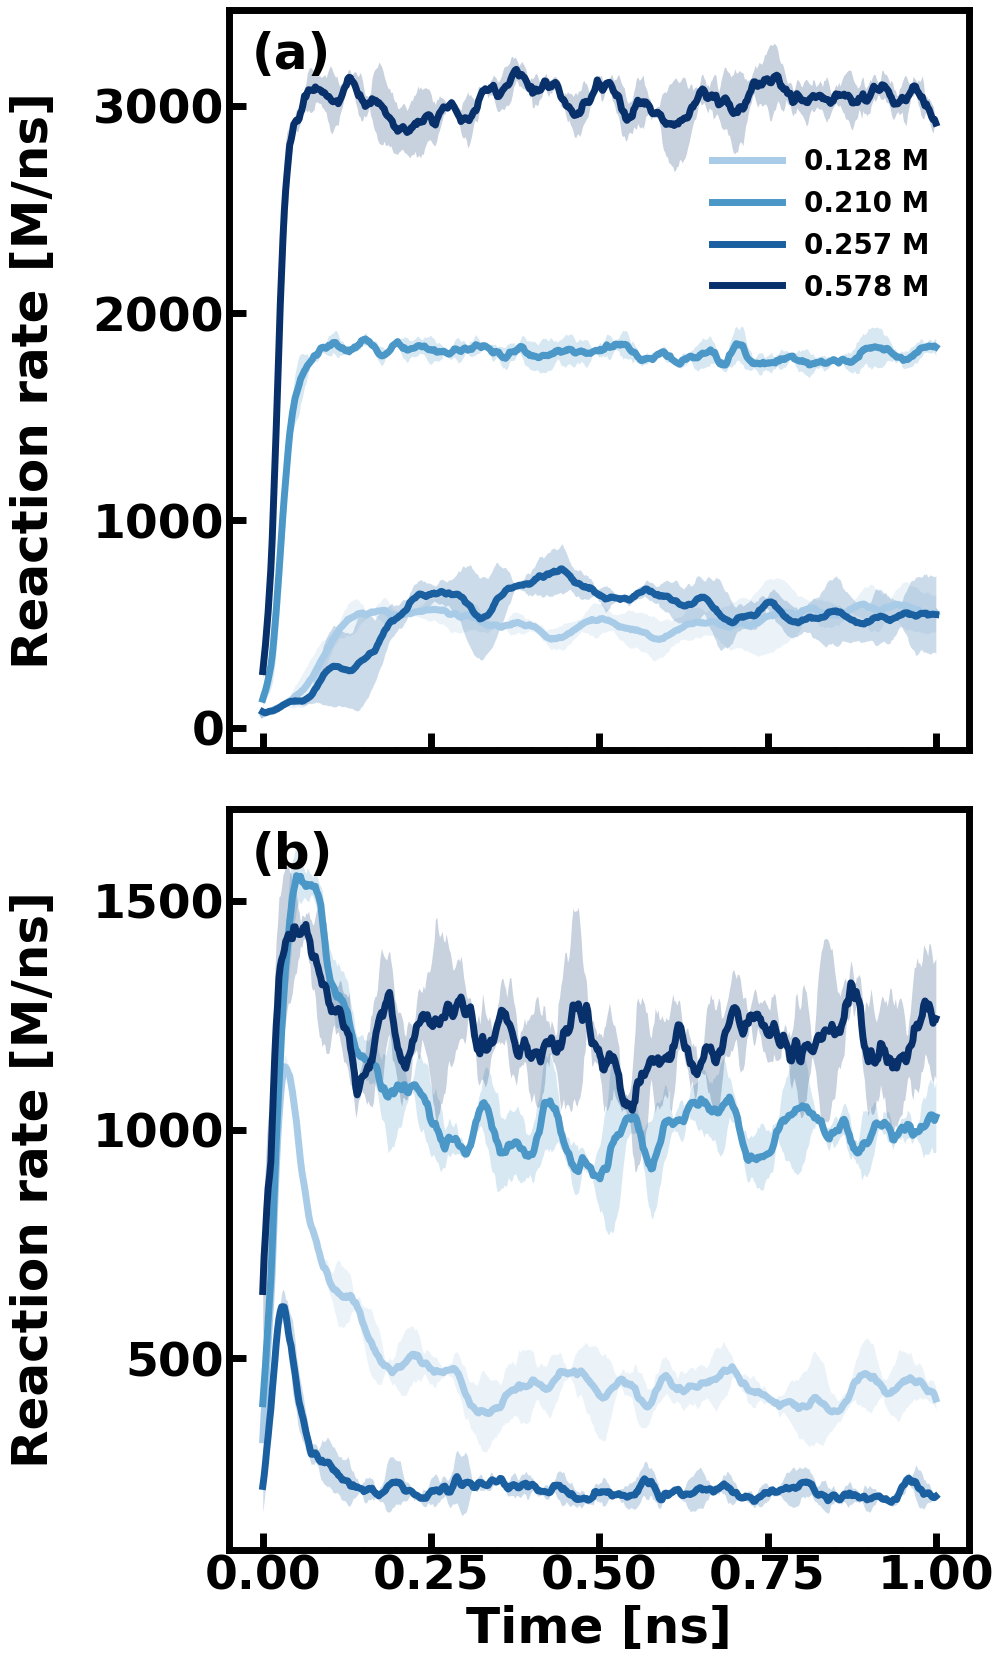


Saved: PE_rate_compare_stacked_ACS_panels.png
Saved: PE_rate_compare_stacked_ACS_panels.pdf


In [1]:
#!/usr/bin/env python3
"""
Journal-quality stacked ACS-like plot with shared x-axis:

(a) Top panel:
    Polymer reaction rate normalized using:
      - reaction data from Polymer/<PE_SYSTEM>/Replica*/log.lammps
      - volume from Water/TMA_OH_water/<CONCENTRATION>/Reacter_3.0/Replica*/log.lammps

(b) Bottom panel:
    Water reaction rate normalized using:
      - reaction + volume data from Water/TMA_OH_water/<CONCENTRATION>/Reacter_3.0/Replica*/log.lammps

Replica filter: exactly REQUIRED_REPLICAS replicas must be found for both
polymer and water sides — if not, the system is skipped with a warning.

Outputs:
  PE_rate_compare_stacked_ACS_panels.png
  PE_rate_compare_stacked_ACS_panels.pdf
  water_system_volume_reaction_summary.csv
"""

from glob import glob
import os
import re
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

# =========================================================
# SETTINGS
# =========================================================
POLYMER_BASE      = "/blue/jsampath/avemula/Paper1_PE/Polymer"
WATER_BASE        = "/blue/jsampath/avemula/Paper1_PE/Water/TMA_OH_water"

REQUIRED_REPLICAS = 3      # enforce this many replicas for every system

# Map each polymer system to its matching water concentration folder
SYSTEM_MAP = {
    "PE_A1": "0.257M",
    "PE_A2": "0.128M",
    "PE_P1": "0.578M",
    "PE_P2": "0.210M",
}

# Display labels for the legend (concentration string -> label shown on plot)
DISPLAY_LABELS = {
    "0.128M": "0.128 M",
    "0.210M": "0.210 M",
    "0.257M": "0.257 M",
    "0.578M": "0.578 M",
}

POLYMER_SYSTEMS = list(SYSTEM_MAP.keys())
WATER_SYSTEMS   = list(SYSTEM_MAP.values())

DT_FS       = 1.0
ROLL_POINTS = 25
NA          = 6.02214076e23
ANG3_TO_L   = 1e-27
BAND_ALPHA  = 0.22
XMAX_NS     = None

OUT_PREFIX  = "PE_rate_compare_stacked_ACS_panels"
SUMMARY_CSV = "water_system_volume_reaction_summary.csv"

STEP_COL     = "Step"
RXN_COL      = "f_myrxns[1]"
Y_LABEL_SIZE = 48

# =========================================================
# COLORS — Wong colorblind-safe palette
# =========================================================
CONC_COLORS = {
    "0.128M": "#A8CBE8",   # black
    "0.210M": "#4A97C8",   # amber
    "0.257M": "#1A5FA0",   # sky blue
    "0.578M": "#08306B",   # teal
}

def poly_color(poly_system):
    return CONC_COLORS.get(SYSTEM_MAP.get(poly_system, ""), "gray")

# =========================================================
# ACS-LIKE RCPARAMS
# =========================================================
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "mathtext.fontset": "dejavusans",
    "mathtext.default": "regular",

    "font.size": 22,
    "axes.labelsize": 34,
    "axes.labelweight": "bold",
    "axes.linewidth": 5.0,

    "xtick.labelsize": 34,
    "ytick.labelsize": 34,
    "xtick.major.size": 12,
    "ytick.major.size": 12,
    "xtick.major.width": 5.0,
    "ytick.major.width": 5.0,
    "xtick.minor.width": 3.0,
    "ytick.minor.width": 3.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": False,
    "ytick.right": False,

    "legend.frameon": False,
    "lines.linewidth": 5.0,
})

# =========================================================
# REPLICA FILTER
# =========================================================
def filter_to_n_replicas(paths, n, label):
    if len(paths) < n:
        raise ValueError(
            f"[{label}] Only {len(paths)} replica(s) found but "
            f"{n} are required. Paths found:\n" +
            "\n".join(f"  {p}" for p in paths)
        )
    if len(paths) > n:
        kept    = paths[:n]
        dropped = paths[n:]
        print(
            f"  [{label}] {len(paths)} replicas found — "
            f"keeping first {n}, dropping:\n" +
            "\n".join(f"    {p}" for p in dropped)
        )
        return kept
    return paths   # exactly n

# =========================================================
# HELPERS
# =========================================================
def extract_replica_number(path):
    m = re.search(r"/Replica(\d+)/", path)
    if m:
        return int(m.group(1))
    raise ValueError(f"Could not extract replica number from: {path}")

def _find_col_case_insensitive(df, targets):
    cols_lower = {c.lower(): c for c in df.columns}
    for t in targets:
        if t.lower() in cols_lower:
            return cols_lower[t.lower()]
    return None

# =========================================================
# READ THERMO TABLE
# =========================================================
def read_thermo_table(filepath):
    with open(filepath, "r", errors="ignore") as f:
        lines = f.readlines()

    header = None
    header_idx = None
    for i, line in enumerate(lines):
        cols = line.split()
        if STEP_COL in cols and RXN_COL in cols:
            header = cols
            header_idx = i
            break

    if header is None:
        raise ValueError(
            f"Could not find thermo header with '{STEP_COL}' and "
            f"'{RXN_COL}' in:\n  {filepath}"
        )

    rows = []
    for line in lines[header_idx + 1:]:
        parts = line.split()
        if len(parts) != len(header):
            continue
        try:
            float(parts[header.index(STEP_COL)])
        except Exception:
            continue
        rows.append(parts)

    df = pd.DataFrame(rows, columns=header)
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="ignore")
    df[STEP_COL] = pd.to_numeric(df[STEP_COL], errors="coerce")
    df[RXN_COL]  = pd.to_numeric(df[RXN_COL],  errors="coerce")
    df = (df.dropna(subset=[STEP_COL, RXN_COL])
            .sort_values(STEP_COL)
            .reset_index(drop=True))
    return df

# =========================================================
# VOLUME: SINGLE MEAN VALUE (used for top panel)
# =========================================================
def read_mean_volume_from_log(filepath):
    with open(filepath, "r", errors="ignore") as f:
        lines = f.readlines()

    for i, line in enumerate(lines):
        cols       = line.split()
        cols_lower = [c.lower() for c in cols]
        has_step   = "step" in cols_lower
        has_vol    = "vol" in cols_lower or "volume" in cols_lower
        has_box    = ("lx" in cols_lower and "ly" in cols_lower
                      and "lz" in cols_lower)

        if has_step and (has_vol or has_box):
            header = cols
            rows   = []
            for line2 in lines[i + 1:]:
                parts = line2.split()
                if len(parts) != len(header):
                    continue
                try:
                    si = next(j for j, c in enumerate(header)
                              if c.lower() == "step")
                    float(parts[si])
                except Exception:
                    continue
                rows.append(parts)

            if rows:
                df = pd.DataFrame(rows, columns=header)
                for c in df.columns:
                    df[c] = pd.to_numeric(df[c], errors="coerce")

                vol_col = _find_col_case_insensitive(df, ["Vol", "Volume"])
                if vol_col is not None:
                    v = df[vol_col].to_numpy(dtype=float)
                    v = v[np.isfinite(v)]
                    if len(v) > 0:
                        return float(np.mean(v) * ANG3_TO_L)

                lx_c = _find_col_case_insensitive(df, ["Lx"])
                ly_c = _find_col_case_insensitive(df, ["Ly"])
                lz_c = _find_col_case_insensitive(df, ["Lz"])
                if all(c is not None for c in [lx_c, ly_c, lz_c]):
                    v = (df[lx_c].to_numpy(dtype=float) *
                         df[ly_c].to_numpy(dtype=float) *
                         df[lz_c].to_numpy(dtype=float))
                    v = v[np.isfinite(v)]
                    if len(v) > 0:
                        return float(np.mean(v) * ANG3_TO_L)

    box_re = re.compile(
        r"orthogonal box\s*=\s*\(([-+0-9.eE]+)\s+([-+0-9.eE]+)\s+([-+0-9.eE]+)\)"
        r"\s+to\s+\(([-+0-9.eE]+)\s+([-+0-9.eE]+)\s+([-+0-9.eE]+)\)"
    )
    vols = []
    for line in lines:
        m = box_re.search(line)
        if m:
            xlo, ylo, zlo, xhi, yhi, zhi = map(float, m.groups())
            vols.append((xhi - xlo) * (yhi - ylo) * (zhi - zlo))

    if vols:
        return float(np.mean(vols) * ANG3_TO_L)

    raise ValueError(f"Could not determine volume from:\n  {filepath}")

# =========================================================
# VOLUME: PER-ROW ARRAY (used for bottom panel)
# =========================================================
def volume_liters_array_from_log(filepath, df):
    vol_col = _find_col_case_insensitive(df, ["Vol", "Volume"])
    if vol_col is not None:
        v = pd.to_numeric(df[vol_col], errors="coerce").values
        if np.isfinite(v).any():
            return v * ANG3_TO_L

    lx_c = _find_col_case_insensitive(df, ["Lx", "LX"])
    ly_c = _find_col_case_insensitive(df, ["Ly", "LY"])
    lz_c = _find_col_case_insensitive(df, ["Lz", "LZ"])
    if all(c is not None for c in [lx_c, ly_c, lz_c]):
        lx = pd.to_numeric(df[lx_c], errors="coerce").values
        ly = pd.to_numeric(df[ly_c], errors="coerce").values
        lz = pd.to_numeric(df[lz_c], errors="coerce").values
        v  = lx * ly * lz
        if np.isfinite(v).any():
            return v * ANG3_TO_L

    box_re = re.compile(
        r"orthogonal box\s*=\s*\(([-+0-9.eE]+)\s+([-+0-9.eE]+)\s+([-+0-9.eE]+)\)"
        r"\s+to\s+\(([-+0-9.eE]+)\s+([-+0-9.eE]+)\s+([-+0-9.eE]+)\)"
    )
    last_box = None
    with open(filepath, "r", errors="ignore") as f:
        for line in f:
            m = box_re.search(line)
            if m:
                xlo, ylo, zlo, xhi, yhi, zhi = map(float, m.groups())
                last_box = (xhi - xlo, yhi - ylo, zhi - zlo)

    if last_box is not None:
        lx, ly, lz = last_box
        return np.full(len(df), lx * ly * lz * ANG3_TO_L, dtype=float)

    raise ValueError(
        f"Could not determine volume for:\n  {filepath}\n"
        "Add Vol (or Lx Ly Lz) to thermo_style, or ensure the log "
        "contains an 'orthogonal box =' line."
    )

# =========================================================
# RATE COMPUTATION
# =========================================================
def _rolling_rate(df, time_ns):
    rxn   = df[RXN_COL].values.astype(float)
    dr    = np.diff(rxn)
    dt    = np.diff(time_ns)
    rate  = np.full(len(rxn), np.nan, dtype=float)
    valid = dt != 0
    rate[1:][valid] = dr[valid] / dt[valid]   # reactions / ns

    out = pd.DataFrame({"time_ns": time_ns, "rate": rate})
    if ROLL_POINTS and ROLL_POINTS > 1:
        out["rate_roll"] = out["rate"].rolling(
            ROLL_POINTS, center=True, min_periods=2
        ).mean()
    else:
        out["rate_roll"] = out["rate"]
    return out

def compute_top_rate(df_rxn, volume_L):
    """Polymer reactions / (NA * mean water volume) -> units: M/ns"""
    time_ns = df_rxn[STEP_COL].values.astype(float) * DT_FS * 1e-6
    out = _rolling_rate(df_rxn, time_ns)
    out["y"] = out["rate_roll"] / (NA * float(volume_L))
    return out

def compute_bottom_rate(df, V_L):
    """Water reactions / (NA * per-row water volume) -> units: M/ns"""
    time_ns = df[STEP_COL].values.astype(float) * DT_FS * 1e-6
    out = _rolling_rate(df, time_ns)
    V_L = np.asarray(V_L, dtype=float)
    if V_L.shape[0] != out.shape[0]:
        raise ValueError("V_L length does not match thermo rows.")
    out["y"] = out["rate_roll"] / (NA * V_L)
    return out

# =========================================================
# REPLICA AVERAGING ON COMMON TIME GRID
# =========================================================
def average_replicas(rep_list, n_interp=500):
    t_min  = max(r["time_ns"].dropna().iloc[0]  for r in rep_list)
    t_max  = min(r["time_ns"].dropna().iloc[-1] for r in rep_list)
    t_grid = np.linspace(t_min, t_max, n_interp)

    mat = []
    for r in rep_list:
        t    = r["time_ns"].values
        y    = r["y"].values
        mask = np.isfinite(y)
        mat.append(np.interp(t_grid, t[mask], y[mask]))

    arr  = np.vstack(mat)
    mean = np.nanmean(arr, axis=0)
    std  = np.nanstd(arr, axis=0, ddof=1) if arr.shape[0] > 1 else np.zeros_like(mean)
    return pd.DataFrame({"time_ns": t_grid, "mean": mean, "std": std})

# =========================================================
# BUILD + FILTER MATCHED FILES FOR TOP PANEL
# =========================================================
print("\n" + "=" * 100)
print("BUILDING MATCHED POLYMER / WATER REPLICA FILES FOR TOP PANEL")
print("=" * 100)

TOP_SYSTEM_FILES = {}   # poly_system -> list of dicts

for poly_system, water_conc in SYSTEM_MAP.items():

    raw_poly = sorted(glob(
        f"{POLYMER_BASE}/{poly_system}/Replica*/log.lammps"
    ))
    raw_water = sorted(glob(
        f"{WATER_BASE}/{water_conc}/Reacter_3.0/Replica*/log.lammps"
    ))

    print(f"\n{poly_system}  <->  {water_conc}")
    print(f"  Polymer replicas found : {len(raw_poly)}")
    print(f"  Water   replicas found : {len(raw_water)}")

    try:
        poly_paths  = filter_to_n_replicas(raw_poly,  REQUIRED_REPLICAS,
                                           f"{poly_system} polymer")
        water_paths = filter_to_n_replicas(raw_water, REQUIRED_REPLICAS,
                                           f"{water_conc} water")
    except ValueError as e:
        print(f"  SKIPPING — {e}")
        TOP_SYSTEM_FILES[poly_system] = []
        continue

    poly_map  = {extract_replica_number(p): p for p in poly_paths}
    water_map = {extract_replica_number(w): w for w in water_paths}
    common    = sorted(set(poly_map) & set(water_map))

    if len(common) < REQUIRED_REPLICAS:
        print(
            f"  SKIPPING — only {len(common)} replica number(s) matched "
            f"between polymer and water (need {REQUIRED_REPLICAS})."
        )
        TOP_SYSTEM_FILES[poly_system] = []
        continue

    matched = []
    for rep in common[:REQUIRED_REPLICAS]:
        matched.append({
            "replica":   rep,
            "poly_log":  poly_map[rep],
            "water_log": water_map[rep],
        })
        print(f"  Matched Replica{rep}")

    TOP_SYSTEM_FILES[poly_system] = matched

# =========================================================
# PROCESS TOP PANEL DATA
# =========================================================
print("\n" + "=" * 100)
print("PROCESSING TOP PANEL: POLYMER REACTION + WATER VOLUME")
print("=" * 100)

top_system_stats = {}   # poly_system -> averaged DataFrame

for poly_system in POLYMER_SYSTEMS:
    matched_files = TOP_SYSTEM_FILES.get(poly_system, [])
    if not matched_files:
        print(f"  SKIPPING {poly_system} — no matched files.")
        continue

    reps = []
    for item in matched_files:
        rep, poly_log, water_log = (
            item["replica"], item["poly_log"], item["water_log"]
        )
        try:
            df_rxn   = read_thermo_table(poly_log)
            volume_L = read_mean_volume_from_log(water_log)
            rep_df   = compute_top_rate(df_rxn, volume_L)
            reps.append(rep_df)
            print(
                f"  {poly_system} Replica{rep}: "
                f"mean water volume = {volume_L:.4e} L"
            )
        except Exception as e:
            print(f"  WARNING: Skipping {poly_system} Replica{rep}: {e}")

    if len(reps) == REQUIRED_REPLICAS:
        top_system_stats[poly_system] = average_replicas(reps)
        print(f"  -> Averaged {len(reps)} replicas for {poly_system}.")
    else:
        print(
            f"  SKIPPING {poly_system} — only {len(reps)} replica(s) "
            f"processed successfully (need {REQUIRED_REPLICAS})."
        )

# =========================================================
# BUILD + FILTER WATER FILES FOR BOTTOM PANEL
# =========================================================
print("\n" + "=" * 100)
print("BUILDING WATER FILES FOR BOTTOM PANEL")
print("=" * 100)

BOTTOM_SYSTEM_FILES = {}   # water_conc -> list of paths (exactly REQUIRED_REPLICAS)

for water_conc in WATER_SYSTEMS:
    raw = sorted(glob(
        f"{WATER_BASE}/{water_conc}/Reacter_3.0/Replica*/log.lammps"
    ))
    print(f"\n{water_conc}: {len(raw)} replica(s) found")

    try:
        paths = filter_to_n_replicas(raw, REQUIRED_REPLICAS, water_conc)
        BOTTOM_SYSTEM_FILES[water_conc] = paths
        for p in paths:
            print(f"  Accepted: {p}")
    except ValueError as e:
        print(f"  SKIPPING — {e}")
        BOTTOM_SYSTEM_FILES[water_conc] = []

# =========================================================
# PROCESS BOTTOM PANEL DATA
# =========================================================
print("\n" + "=" * 100)
print("PROCESSING BOTTOM PANEL: WATER REACTION + WATER VOLUME")
print("=" * 100)

bottom_system_stats = {}   # water_conc -> averaged DataFrame
volume_summary      = {}
reaction_summary    = {}

for water_conc, files in BOTTOM_SYSTEM_FILES.items():
    if not files:
        print(f"  SKIPPING {water_conc} — no files.")
        continue

    print(f"\n{'─'*80}")
    print(f"SYSTEM: {water_conc}  ({len(files)} replicas)")
    print(f"{'─'*80}")

    reps              = []
    replica_vols_ang3 = []
    replica_rxns      = []

    for fpath in files:
        try:
            df   = read_thermo_table(fpath)
            V_L  = volume_liters_array_from_log(fpath, df)
            rep  = compute_bottom_rate(df, V_L)
            reps.append(rep)

            final_rxn = float(df[RXN_COL].iloc[-1])
            replica_rxns.append(final_rxn)

            vmean_ang3 = float(np.nanmean(V_L / ANG3_TO_L))
            replica_vols_ang3.append(vmean_ang3)

            rname = os.path.basename(os.path.dirname(fpath))
            print(f"  {rname}")
            print(f"    File         : {fpath}")
            print(f"    Mean volume  : {vmean_ang3:.4f} Å³  "
                  f"({vmean_ang3 * ANG3_TO_L:.4e} L)")
            print(f"    Final rxns   : {final_rxn:.0f}")

        except Exception as e:
            print(f"  WARNING: Skipping {fpath}: {e}")

    if len(reps) == REQUIRED_REPLICAS:
        bottom_system_stats[water_conc] = average_replicas(reps)
        print(f"  -> Averaged {len(reps)} replicas for {water_conc}.")

        va = np.asarray(replica_vols_ang3, dtype=float)
        volume_summary[water_conc] = {
            "mean_ang3": float(np.nanmean(va)),
            "std_ang3":  float(np.nanstd(va, ddof=1)),
            "mean_L":    float(np.nanmean(va)) * ANG3_TO_L,
            "std_L":     float(np.nanstd(va, ddof=1)) * ANG3_TO_L,
        }
        ra = np.asarray(replica_rxns, dtype=float)
        reaction_summary[water_conc] = {
            "mean_rxn": float(np.nanmean(ra)),
            "std_rxn":  float(np.nanstd(ra, ddof=1)),
        }
    else:
        print(
            f"  SKIPPING {water_conc} — only {len(reps)} replica(s) "
            f"processed successfully (need {REQUIRED_REPLICAS})."
        )

# =========================================================
# PRINT + SAVE SUMMARY CSV
# =========================================================
print("\n" + "#" * 80)
print("VOLUME SUMMARY")
print("#" * 80)
for s in WATER_SYSTEMS:
    if s not in volume_summary:
        continue
    v = volume_summary[s]
    print(f"  {s}:  {v['mean_ang3']:.4f} ± {v['std_ang3']:.4f} Å³   "
          f"({v['mean_L']:.4e} ± {v['std_L']:.4e} L)")

print("\n" + "#" * 80)
print("REACTION SUMMARY")
print("#" * 80)
for s in WATER_SYSTEMS:
    if s not in reaction_summary:
        continue
    r = reaction_summary[s]
    print(f"  {s}:  {r['mean_rxn']:.0f} ± {r['std_rxn']:.0f} reactions")

rows = []
for s in WATER_SYSTEMS:
    if s not in volume_summary:
        continue
    v = volume_summary[s]
    r = reaction_summary.get(s, {"mean_rxn": np.nan, "std_rxn": np.nan})
    rows.append({
        "system":           DISPLAY_LABELS.get(s, s),
        "mean_volume_ang3": v["mean_ang3"],
        "std_volume_ang3":  v["std_ang3"],
        "mean_volume_L":    v["mean_L"],
        "std_volume_L":     v["std_L"],
        "mean_reactions":   r["mean_rxn"],
        "std_reactions":    r["std_rxn"],
    })

summary_df = pd.DataFrame(rows)
summary_df.to_csv(SUMMARY_CSV, index=False)
print(f"\nSaved: {SUMMARY_CSV}")
print(summary_df.to_string(index=False))

# =========================================================
# PLOT — stacked panels (a) top  (b) bottom
# =========================================================
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 20),
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)
ax1.set_box_aspect(1)
ax2.set_box_aspect(1)

# concentrations sorted low -> high for consistent legend order
sorted_concs = sorted(
    [s for s in WATER_SYSTEMS if s in bottom_system_stats],
    key=lambda c: float(c.replace("M", ""))
)

# ─────────────────────────────────────────
# TOP PANEL (a)  – polymer reaction rate
# Legend sorted ascending by concentration
# ─────────────────────────────────────────
handles_top, labels_top = [], []

for poly_system in sorted(
    POLYMER_SYSTEMS,
    key=lambda p: float(SYSTEM_MAP[p].replace("M", ""))
):
    if poly_system not in top_system_stats:
        continue

    water_conc = SYSTEM_MAP[poly_system]
    color      = CONC_COLORS.get(water_conc, "gray")
    df         = top_system_stats[poly_system]

    if XMAX_NS is not None:
        df = df[df["time_ns"] <= XMAX_NS]

    x, y, e = df["time_ns"].values, df["mean"].values, df["std"].values
    lbl = DISPLAY_LABELS.get(water_conc, water_conc)
    line, = ax1.plot(x, y, color=color, label=lbl)
    ax1.fill_between(x, y - e, y + e, color=color, alpha=BAND_ALPHA, linewidth=0)
    handles_top.append(line)
    labels_top.append(lbl)

ax1.set_ylabel("Reaction rate [M/ns]", fontsize=36, labelpad=25)
ax1.text(0.03, 0.92, "(a)", transform=ax1.transAxes,
         fontsize=36, fontweight="bold")
ax1.tick_params(labelbottom=False)

leg = ax1.legend(
    handles_top, labels_top,
    loc="center right",
    bbox_to_anchor=(0.98, 0.71),
    fontsize=20,
    frameon=False,
    handlelength=2.5,
)
for txt in leg.get_texts():
    txt.set_fontweight("bold")

# ─────────────────────────────────────────
# BOTTOM PANEL (b) – water reaction rate
# Legend sorted ascending by concentration
# ─────────────────────────────────────────
handles_bot, labels_bot = [], []

for water_conc in sorted_concs:
    color = CONC_COLORS.get(water_conc, "gray")
    df    = bottom_system_stats[water_conc]

    if XMAX_NS is not None:
        df = df[df["time_ns"] <= XMAX_NS]

    x, y, e = df["time_ns"].values, df["mean"].values, df["std"].values
    lbl = DISPLAY_LABELS.get(water_conc, water_conc)
    line, = ax2.plot(x, y, color=color, label=lbl)
    ax2.fill_between(x, y - e, y + e, color=color, alpha=BAND_ALPHA, linewidth=0)
    handles_bot.append(line)
    labels_bot.append(lbl)

ax2.set_xlabel("Time [ns]", fontsize=36, fontweight="bold")
ax2.set_ylabel("Reaction rate [M/ns]", fontsize=36, labelpad=25)
ax2.text(0.03, 0.92, "(b)", transform=ax2.transAxes,
         fontsize=36, fontweight="bold")
ax2.yaxis.set_major_locator(mpl.ticker.MaxNLocator(nbins=4))

# Uncomment below to show legend on bottom panel too
# leg2 = ax2.legend(handles_bot, labels_bot, loc="upper right",
#                   fontsize=20, frameon=False, handlelength=2.5)
# for txt in leg2.get_texts():
#     txt.set_fontweight("bold")

# ─────────────────────────────────────────
# SHARED AXIS STYLE
# ─────────────────────────────────────────
for ax in (ax1, ax2):
    for spine in ax.spines.values():
        spine.set_linewidth(5)
    ax.tick_params(direction="in", width=5, length=12)
    ax.minorticks_on()
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontweight("bold")
        lbl.set_fontsize(34)

fig.tight_layout()
fig.savefig(f"{OUT_PREFIX}.png", dpi=600, bbox_inches="tight")
fig.savefig(f"{OUT_PREFIX}.pdf",              bbox_inches="tight")
plt.show()

print("\nSaved:", f"{OUT_PREFIX}.png")
print("Saved:", f"{OUT_PREFIX}.pdf")